In [1]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo, RecordEpisodeStatistics
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/home/hegemon/RL-Assignments/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup Environment

In [27]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=1000)
spec = env.spec
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")
print(f"Max Episode Steps: {spec.max_episode_steps}")
print(env)
# print P
P = env.unwrapped.P
for state in P:
    for action in P[state]:
        print(f"State {state}, Action {action}: {P[state][action]}")
# env = RecordVideo(env, video_folder="videos", episode_trigger=lambda x: x % 20 == 0)
env.close()

Observation Space: Discrete(48)
Action Space: Discrete(4)
Max Episode Steps: 1000
<TimeLimit<OrderEnforcing<PassiveEnvChecker<CliffWalkingEnv<CliffWalking-v1>>>>>
State 0, Action 0: [(1.0, np.int64(0), -1, False)]
State 0, Action 1: [(1.0, np.int64(1), -1, False)]
State 0, Action 2: [(1.0, np.int64(12), -1, False)]
State 0, Action 3: [(1.0, np.int64(0), -1, False)]
State 1, Action 0: [(1.0, np.int64(1), -1, False)]
State 1, Action 1: [(1.0, np.int64(2), -1, False)]
State 1, Action 2: [(1.0, np.int64(13), -1, False)]
State 1, Action 3: [(1.0, np.int64(0), -1, False)]
State 2, Action 0: [(1.0, np.int64(2), -1, False)]
State 2, Action 1: [(1.0, np.int64(3), -1, False)]
State 2, Action 2: [(1.0, np.int64(14), -1, False)]
State 2, Action 3: [(1.0, np.int64(1), -1, False)]
State 3, Action 0: [(1.0, np.int64(3), -1, False)]
State 3, Action 1: [(1.0, np.int64(4), -1, False)]
State 3, Action 2: [(1.0, np.int64(15), -1, False)]
State 3, Action 3: [(1.0, np.int64(2), -1, False)]
State 4, Action 0

In [33]:
# observation, info = env.reset()
# print(f"Observation: {observation}, Info: {info}")

Observation: 36, Info: {'prob': 1}


In [28]:
done = False
total_reward = 0

observation, info = env.reset()

while not done:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    total_reward += reward

print(f"Total Reward: {total_reward}, Terminated: {terminated}, Truncated: {truncated}")

Total Reward: -7142, Terminated: True, Truncated: False


# Part-A: Action-Value Control

## Monte Carlo Control (e-greedy improvement)

_Pseudocode:_

```python
Initialize Q(s, a) with 0 for all s ∈ S, a ∈ A
Initialize returns(s, a) as an empty list for all s ∈ S, a ∈ A

do:
    Generate an episode using policy ε-greedy behaviour on Q(s, a)
    For each state-action pair (s, a) in the episode calculate the first-visit return G
        Append G to returns(s, a)
        Update Q(s, a) = average(returns(s, a))
while convergence is not achieved
```

In [29]:
import numpy as np
from tqdm import tqdm

def monte_carlo_control_epsilon_greedy(env, num_episodes, gamma=1.0, epsilon=0.1, cumulative_rewards=False):
    # Initialize Q(s, a) with 0
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    # Initialize Returns(s, a) as empty lists
    returns = {(s, a): [] for s in range(env.observation_space.n) for a in range(env.action_space.n)}
    # Initialize cumulative rewards list if needed
    if cumulative_rewards:
        cumulative_rewards_list = []

    # Initialize Pi to be an arbitrary epsilon-greedy policy
    # We'll represent the policy implicitly through Q to save memory/time
    
    for _ in tqdm(range(num_episodes), desc="Training"):
        # 1. Generate an episode using epsilon-greedy policy derived from Q
        state, info = env.reset()
        episode = []
        done = False
        while not done:
            # Epsilon-greedy selection
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])
            
            next_state, reward, terminated, truncated, info = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            done = terminated or truncated

        # 2. Process the episode
        G = 0
        visited_sa = set()
        # Iterate backward to calculate returns
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = gamma * G + r

            if cumulative_rewards:
                cumulative_rewards_list.append(G)
            
            # First-visit check: only update if this (s, a) wasn't visited earlier in episode
            # Since we are moving backward, "earlier" means it won't appear again in our loop
            # But the standard way is to check if episode[:t] contains (s, a)
            # Efficient way:
            is_first_visit = True
            for i in range(t):
                if episode[i][0] == s and episode[i][1] == a:
                    is_first_visit = False
                    break
            
            if is_first_visit:
                returns[(s, a)].append(G)
                Q[s, a] = np.mean(returns[(s, a)])
                # Policy is implicitly updated because we use argmax(Q) in the next episode
                
    if cumulative_rewards:
        return Q, cumulative_rewards_list
    
    return Q

In [30]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=1000)

optimal_Q, cumulative_rewards = monte_carlo_control_epsilon_greedy(env, num_episodes=10000, gamma=1.0, epsilon=0.1, cumulative_rewards=True)
print("Optimal Q-values:")
print(optimal_Q)

# Derive the optimal policy from the optimal Q-values
optimal_policy = np.argmax(optimal_Q, axis=1)
print("Optimal Policy (0=Up, 1=Right, 2=Down, 3=Left):")
print(optimal_policy)

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

Training: 100%|██████████| 10000/10000 [01:14<00:00, 133.40it/s]

Optimal Q-values:
[[-9.09907563e+02 -1.02375200e+03 -3.42713889e+02 -9.06463415e+02]
 [-7.90944444e+02 -8.23309524e+02 -1.81542729e+02 -7.65540541e+02]
 [-1.98423174e+02 -2.44805222e+01 -1.80214118e+02 -2.40743707e+02]
 [-9.65726660e+01 -1.87255441e+01 -8.89538462e+01 -1.27706740e+02]
 [-6.52835821e+01 -1.60809993e+01 -6.84824903e+01 -1.03859316e+02]
 [-4.97374670e+01 -1.24842081e+01 -5.24881423e+01 -5.55768322e+01]
 [-3.87339744e+01 -1.02202995e+01 -4.97326007e+01 -6.16516517e+01]
 [-3.10100671e+01 -8.60346399e+00 -4.16403162e+01 -2.43378378e+01]
 [-1.88417508e+01 -7.15253550e+00 -2.27993311e+01 -2.37614379e+01]
 [-1.34025974e+01 -5.71232163e+00 -1.34424460e+01 -1.49255319e+01]
 [-8.95752896e+00 -4.60980833e+00 -7.68478261e+00 -1.02723577e+01]
 [-7.71171171e+00 -6.82520325e+00 -3.51218730e+00 -7.84452297e+00]
 [-4.09495522e+02 -2.95295449e+01 -2.14852201e+02 -2.38193431e+02]
 [-2.86201531e+02 -2.73650167e+01 -1.89737003e+02 -2.28562147e+02]
 [-2.43242795e+01 -1.34532033e+02 -1.5929393

In [31]:
# Visualize the optimal policy
action_mapping = {0: '↑', 1: '→', 2: '↓', 3: '←'}
policy_grid = np.array([action_mapping[a] for a in optimal_policy]).reshape((4, 12))
print("Optimal Policy Grid:")
print(policy_grid)

Optimal Policy Grid:
[['↓' '↓' '→' '→' '→' '→' '→' '→' '→' '→' '→' '↓']
 ['→' '→' '↑' '→' '→' '→' '↑' '←' '↑' '→' '→' '↓']
 ['↑' '↑' '↑' '←' '←' '←' '↓' '←' '→' '→' '↑' '↓']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']]


In [13]:
# Play a few episodes with the optimal policy to see it in action and record the video

env = RecordVideo(env, video_folder="videos", episode_trigger=lambda x: True)  # Record every episode for testing

num_test_episodes = 5
for episode in range(num_test_episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    print(f"\nEpisode {episode + 1}:")
    while not done:
        action = optimal_policy[state]
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
        # Uncomment the following line to render the environment (may not work in all environments)
        # env.render()
    print(f"Total Reward: {total_reward}, Terminated: {terminated}, Truncated: {truncated}")


Episode 1:
Total Reward: -21, Terminated: True, Truncated: False

Episode 2:
Total Reward: -21, Terminated: True, Truncated: False

Episode 3:
Total Reward: -21, Terminated: True, Truncated: False

Episode 4:
Total Reward: -21, Terminated: True, Truncated: False

Episode 5:
Total Reward: -21, Terminated: True, Truncated: False


In [32]:
env.close()

## SARSA (on-policy TD control)

_Pseudocode:_

```python
Initialize Q(s, a) with arbitrary values for all s ∈ S, a ∈ A

do:
    Initialize s
    Choose a from s using policy ε-greedy behaviour on Q(s, a)
    For each step of the episode:
        Take action a, observe reward R and next state s'
        Choose a' from s' using policy ε-greedy behaviour on Q(s', a')
        Q(s, a) = Q(s, a) + α * [R + γ * Q(s', a') - Q(s, a)]
        s = s'
        a = a'
while convergence is not achieved
```

In [33]:
def sarsa_control_epsilon_greedy(env, num_episodes, gamma=1.0, alpha=0.1, epsilon=0.1, cumulative_rewards=False):
    # Initialize Q(s, a) with 0
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    # Initialize cumulative rewards list if needed
    if cumulative_rewards:
        cumulative_rewards_list = []
    
    for _ in tqdm(range(num_episodes), desc="Training SARSA"):
        state, info = env.reset()
        # Choose action using epsilon-greedy policy derived from Q
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        
        done = False
        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            # Choose next action using epsilon-greedy policy derived from Q
            if np.random.rand() < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = np.argmax(Q[next_state])
            
            # Update Q(s, a) using the SARSA update rule
            Q[state, action] += alpha * (reward + gamma * Q[next_state, next_action] - Q[state, action])
            
            state = next_state
            action = next_action
            if cumulative_rewards:
                cumulative_rewards_list.append(reward)
                
    if cumulative_rewards:
        return Q, cumulative_rewards_list
    return Q

In [34]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array", max_episode_steps=1000)
optimal_Q_sarsa, cumulative_rewards_sarsa = sarsa_control_epsilon_greedy(env, num_episodes=10000, gamma=1.0, alpha=0.1, epsilon=0.1, cumulative_rewards=True)
print("Optimal Q-values from SARSA:")
print(optimal_Q_sarsa)
env.close()


Training SARSA:   0%|          | 0/10000 [00:00<?, ?it/s]

Training SARSA: 100%|██████████| 10000/10000 [00:03<00:00, 3215.06it/s]

Optimal Q-values from SARSA:
[[ -16.63274782  -15.49986694  -17.76949718  -16.91053307]
 [ -15.78440685  -14.47217547  -16.23269562  -16.88192515]
 [ -14.48686136  -13.12531734  -14.9790115   -15.89211449]
 [ -13.18323196  -12.05612491  -13.46170049  -14.45699386]
 [ -12.08375741  -10.96509003  -11.95263528  -13.45067111]
 [ -10.95815935   -9.82634945  -10.60629059  -12.30560531]
 [  -9.98619621   -8.79908137   -9.16624099  -11.23071275]
 [  -8.8406714    -7.83234427   -7.9909682    -9.99470265]
 [  -7.72558086   -6.99921315   -6.66645257   -9.0373578 ]
 [  -6.50886865   -5.42433486   -5.78769551   -8.21185406]
 [  -5.39240805   -4.27435088   -4.78308525   -6.78055744]
 [  -4.54099536   -4.29174656   -3.28634403   -5.63210048]
 [ -16.70017262  -15.17218175  -17.71009222  -16.10068651]
 [ -15.4438508   -14.13274369  -16.45495019  -16.57106814]
 [ -14.21600147  -13.05540513  -15.97922089  -15.16707452]
 [ -13.277331    -12.13303467  -15.04904701  -14.01270613]
 [ -12.07912006  -10.207218

In [35]:
optimal_policy = np.argmax(optimal_Q_sarsa, axis=1)
print("Optimal Policy from SARSA (0=Up, 1=Right, 2=Down, 3=Left):")
print(optimal_policy)

Optimal Policy from SARSA (0=Up, 1=Right, 2=Down, 3=Left):
[1 1 1 1 1 1 1 1 2 1 1 2 1 1 1 1 1 1 1 1 1 1 1 2 0 0 0 0 0 0 0 0 0 0 1 2 0
 0 0 0 0 0 0 0 0 0 0 0]


In [36]:
# Visualize the optimal policy from SARSA
policy_grid_sarsa = np.array([action_mapping[a] for a in optimal_policy]).reshape((4, 12))
print("Optimal Policy Grid from SARSA:")
print(policy_grid_sarsa)

Optimal Policy Grid from SARSA:
[['→' '→' '→' '→' '→' '→' '→' '→' '↓' '→' '→' '↓']
 ['→' '→' '→' '→' '→' '→' '→' '→' '→' '→' '→' '↓']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '→' '↓']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']]


In [23]:
env = RecordVideo(env, video_folder="videos_sarsa", episode_trigger=lambda x: True)  # Record every episode for testing
num_test_episodes = 5
for episode in range(num_test_episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    print(f"\nSARSA Episode {episode + 1}:")
    while not done:
        action = optimal_policy[state]
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    print(f"Total Reward: {total_reward}, Terminated: {terminated}, Truncated: {truncated}")

env.close()


SARSA Episode 1:
Total Reward: -17, Terminated: True, Truncated: False

SARSA Episode 2:
Total Reward: -17, Terminated: True, Truncated: False

SARSA Episode 3:
Total Reward: -17, Terminated: True, Truncated: False

SARSA Episode 4:
Total Reward: -17, Terminated: True, Truncated: False

SARSA Episode 5:
Total Reward: -17, Terminated: True, Truncated: False


## Tasks
1. Compare Cumulative Rewards: Plot the cumulative rewards obtained by both algorithms over episodes to visualize their learning progress.
2. Optimal Policy Visualization: Visualize the optimal policy derived from both algorithms using a grid representation of the environment, showing the action chosen for each state.
3. Convergence Analysis: Analyze the convergence of both algorithms by plotting the value function estimates over episodes and discussing their stability and efficiency in learning the optimal policy.

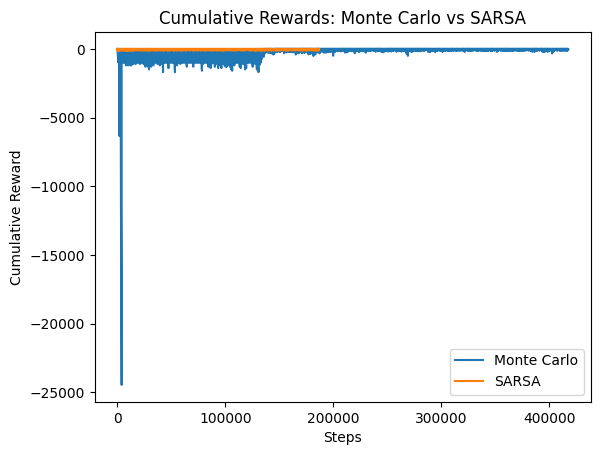

In [39]:
# Task 1: Compare Cumulative Rewards

plt.plot(cumulative_rewards, label="Monte Carlo")
plt.plot(cumulative_rewards_sarsa, label="SARSA")
plt.xlabel("Steps")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Rewards: Monte Carlo vs SARSA")
plt.legend()
plt.show()


In [ ]:
# How to check for stability and convergence of the learned policies?

# Answer: To check for stability and convergence of the learned policies, we can monitor the cumulative rewards over time. If the cumulative rewards stabilize and do not show significant fluctuations, it may indicate that the policy has converged. Additionally, we can compare the learned policies at different stages of training to see if they are becoming more similar, which can also indicate convergence.
# What about stability? How can we check if the learned policy is stable?
# Answer: To check if the learned policy is stable, we can evaluate the policy on a set of test episodes and observe the total rewards obtained. If the total rewards are consistently high and do not vary significantly across different test episodes, it may indicate that the policy is stable. Additionally, we can visualize the policy's behavior in the environment to see if it consistently takes reasonable actions.